# Buenos Aires Household Survey

English-first companion notebook for the portfolio version of the project.

## Purpose

This notebook is the clean public-facing companion to the project. It reads the exported outputs produced by `scripts/household_analysis.py`, highlights the main metrics, and keeps the repository understandable for an international audience.

The original exploratory notebook in Spanish is preserved in `archive/household_survey_analysis_legacy_es.ipynb`.

In [1]:
from pathlib import Path
from IPython.display import Image, display

BASE_DIR = Path.cwd()
required_paths = [
    BASE_DIR / r'outputs/tables/commune_income_summary.csv',
    BASE_DIR / r'outputs/tables/education_income_summary.csv',
    BASE_DIR / r'outputs/tables/marital_status_income_summary.csv',
    BASE_DIR / r'outputs/figures/median_household_income_by_commune.png',
    BASE_DIR / r'outputs/figures/average_income_by_education.png',
]

missing = [str(path) for path in required_paths if not path.exists()]
if missing:
    missing_list = '\n- '.join(missing)
    raise FileNotFoundError(
        f"Run `python scripts/household_analysis.py` first. Missing files:\n- {missing_list}"
    )

print('All required outputs are available.')


All required outputs are available.


In [2]:
from pathlib import Path
import pandas as pd

BASE_DIR = Path.cwd()
commune_summary = pd.read_csv(BASE_DIR / 'outputs/tables/commune_income_summary.csv')
education_summary = pd.read_csv(BASE_DIR / 'outputs/tables/education_income_summary.csv')
marital_summary = pd.read_csv(BASE_DIR / 'outputs/tables/marital_status_income_summary.csv')

household_count = int(commune_summary['households'].sum())
commune_count = int(commune_summary['commune'].nunique())
top_commune = commune_summary.iloc[0]
bottom_commune = commune_summary.iloc[-1]

print(f'Households analyzed: {household_count:,}')
print(f'Communes covered: {commune_count}')
print(f"Top commune by median household income: Commune {int(top_commune['commune'])} ({top_commune['median_household_income']:.0f})")
print(f"Bottom commune by median household income: Commune {int(bottom_commune['commune'])} ({bottom_commune['median_household_income']:.0f})")
print('\nTop education groups by average total income:')
print(education_summary.head(5).to_string(index=False))
print('\nMarital-status view:')
print(marital_summary.head(5).to_string(index=False))

Households analyzed: 5,848
Communes covered: 15
Top commune by median household income: Commune 14 (70000)
Bottom commune by median household income: Commune 8 (35000)

Top education groups by average total income:
                    education_level  people  median_total_income  average_total_income
                  General secondary    3672              43000.0          54176.359477
              Other special schools    2570              23000.0          28384.871206
                    Special primary    2194              20000.0          23738.250684
                    General primary     939              15000.0          18991.961661
Basic general education (years 1-9)    1516              13000.0          17101.443272

Marital-status view:
marital_status  people  median_per_capita_income
   Unspecified       1                   47500.0
      Divorced     516                   28750.0
       Widowed     797                   24000.0
       Married    3511                   2266

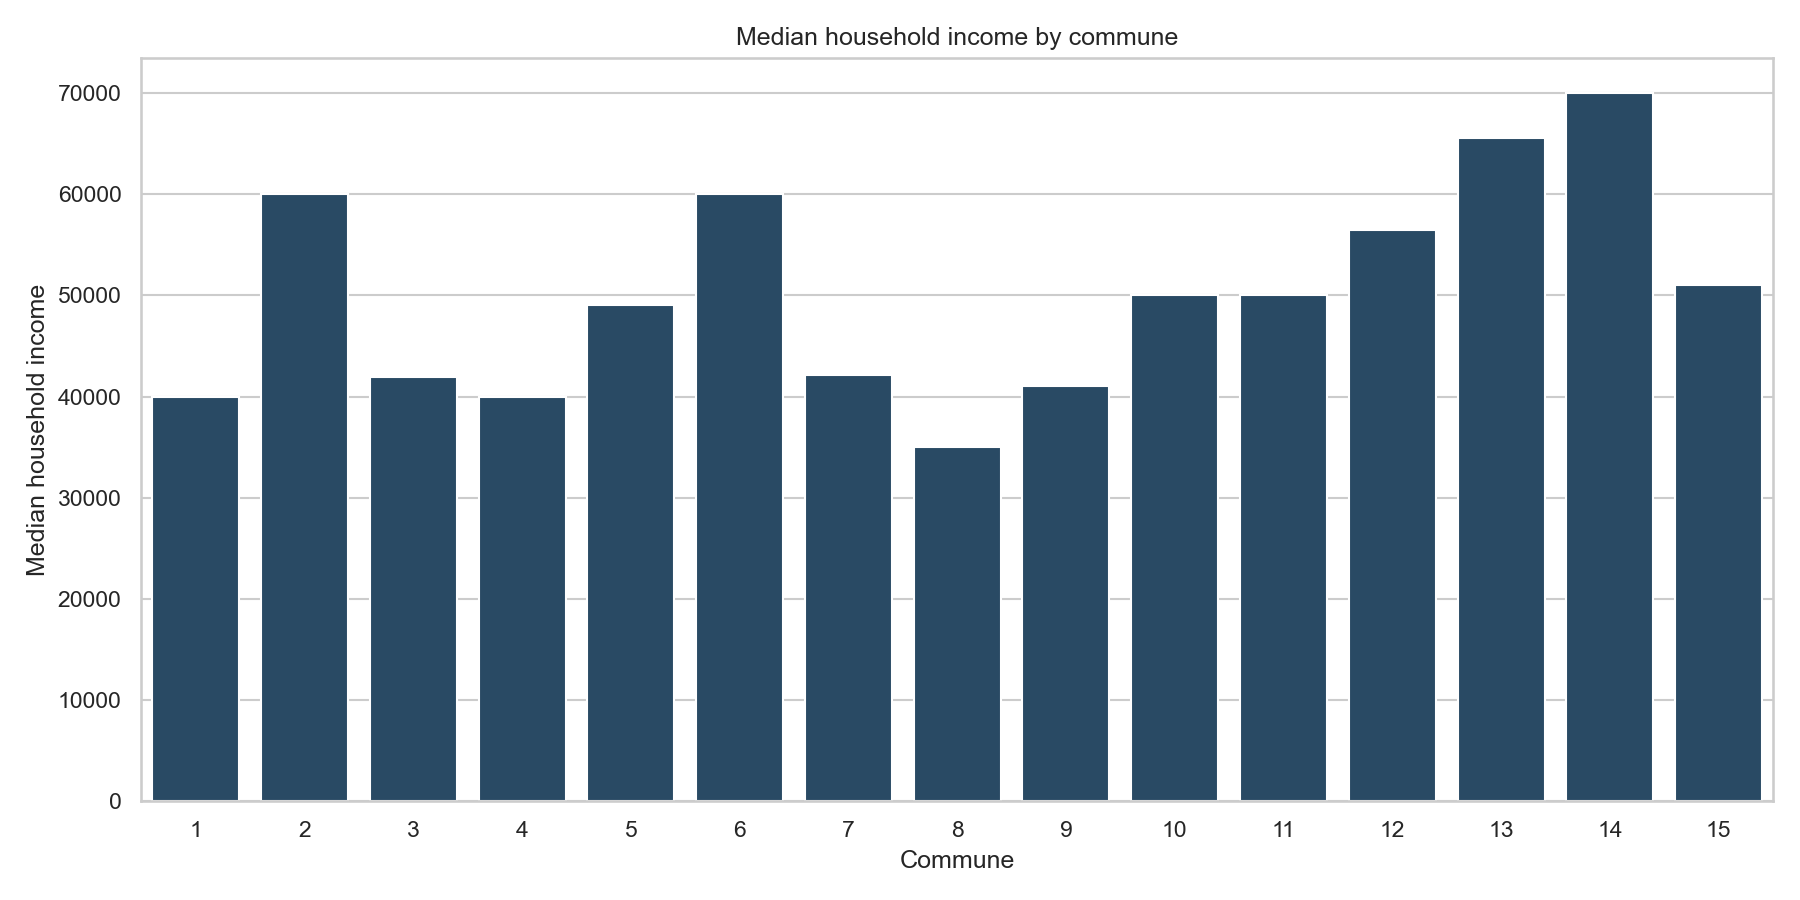

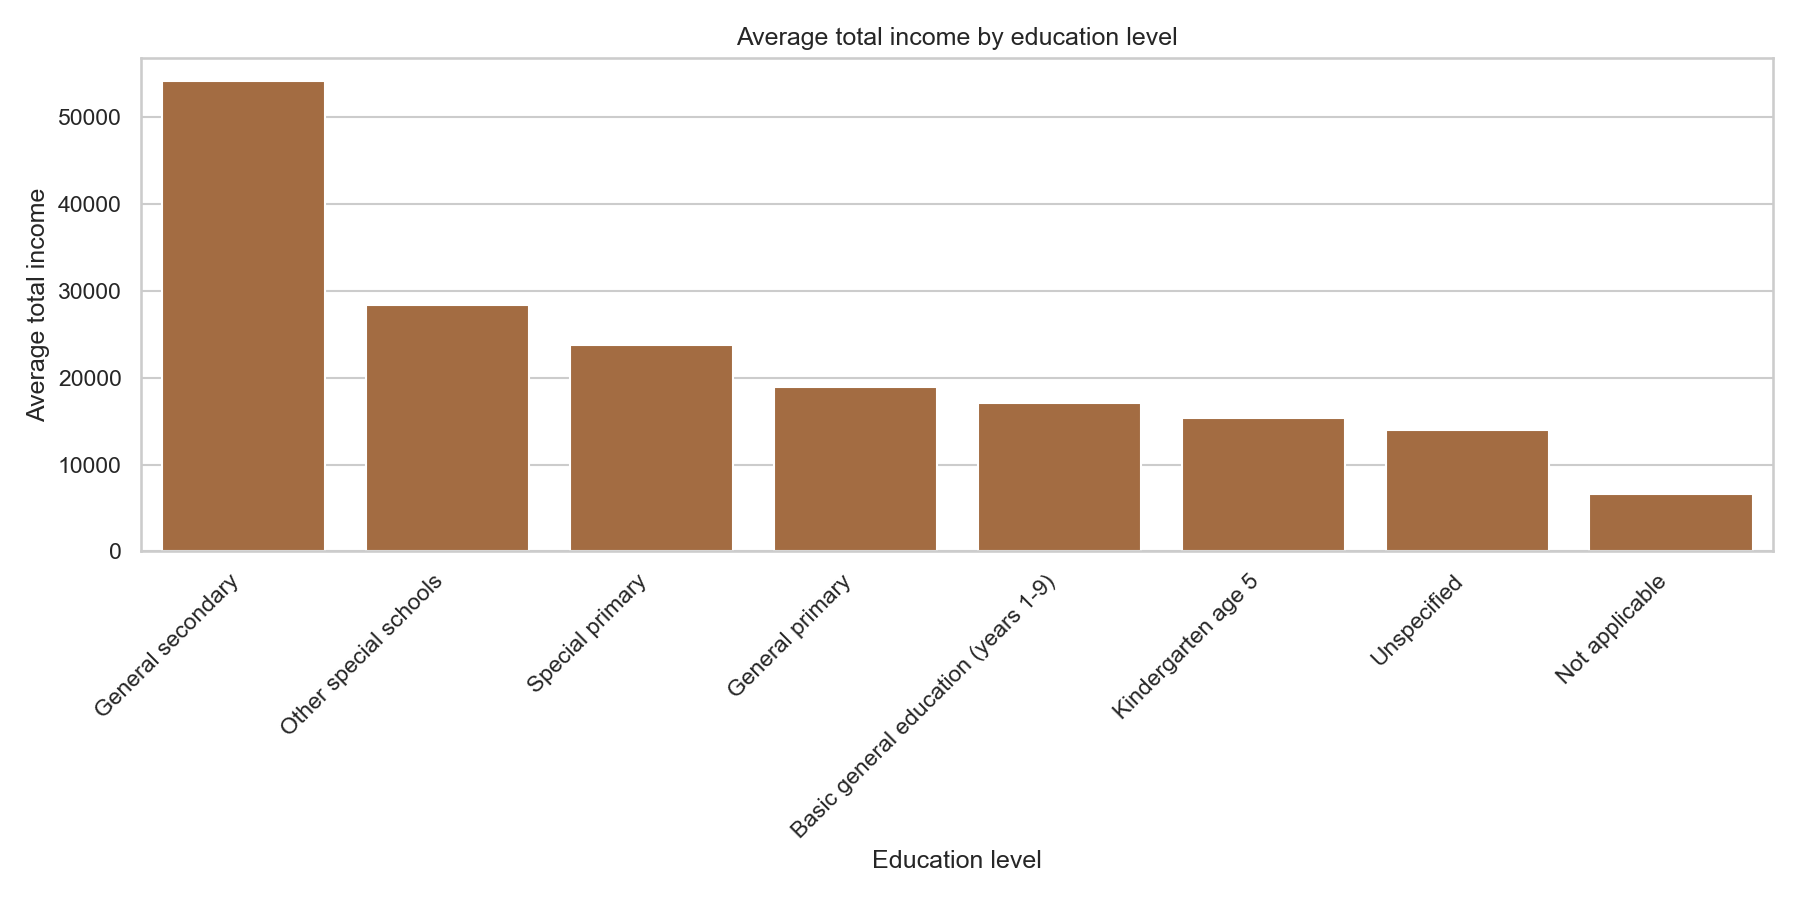

In [3]:
for figure_path in [
    BASE_DIR / r'outputs/figures/median_household_income_by_commune.png',
    BASE_DIR / r'outputs/figures/average_income_by_education.png',
]:
    display(Image(filename=str(figure_path)))
